Using device: cpu


100%|██████████| 170M/170M [00:18<00:00, 9.12MB/s]


Using 10000 training images, 10000 test images


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Starting training...
Epoch 1/8 | Train Loss: 1.4364 | Train Acc: 50.45% | Val Loss: 1.1767 | Val Acc: 59.54%
Epoch 2/8 | Train Loss: 1.0624 | Train Acc: 63.75% | Val Loss: 1.1142 | Val Acc: 61.91%
Epoch 3/8 | Train Loss: 0.9165 | Train Acc: 69.18% | Val Loss: 0.9589 | Val Acc: 68.14%
Epoch 4/8 | Train Loss: 0.8208 | Train Acc: 71.74% | Val Loss: 0.8973 | Val Acc: 69.49%
Epoch 5/8 | Train Loss: 0.7298 | Train Acc: 75.72% | Val Loss: 0.8442 | Val Acc: 72.24%
Epoch 6/8 | Train Loss: 0.6863 | Train Acc: 76.45% | Val Loss: 0.8441 | Val Acc: 71.34%
Epoch 7/8 | Train Loss: 0.6159 | Train Acc: 79.09% | Val Loss: 0.8028 | Val Acc: 73.62%
Epoch 8/8 | Train Loss: 0.5728 | Train Acc: 80.63% | Val Loss: 0.8173 | Val Acc: 73.50%

✅ Training Completed!


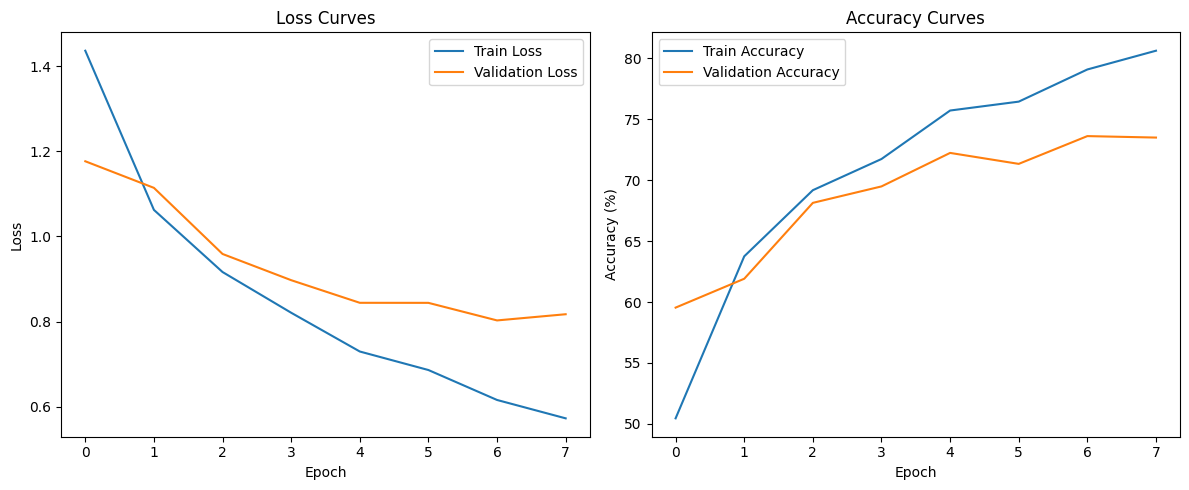


=== Final Evaluation Metrics ===
              precision    recall  f1-score   support

    airplane       0.66      0.85      0.75      1000
  automobile       0.88      0.81      0.84      1000
        bird       0.70      0.61      0.65      1000
         cat       0.54      0.62      0.58      1000
        deer       0.71      0.74      0.72      1000
         dog       0.73      0.51      0.60      1000
        frog       0.80      0.82      0.81      1000
       horse       0.74      0.78      0.76      1000
        ship       0.84      0.80      0.82      1000
       truck       0.81      0.81      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000


✅ Model saved as 'cifar10_resnet18.pth'

Model is ready for inference!


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation + Normalization
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10 (small subset for faster training)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Use only 20% of training data for speed
train_size = int(0.2 * len(trainset))
trainset, _ = torch.utils.data.random_split(trainset, [train_size, len(trainset)-train_size])

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print(f"Using {train_size} training images, {len(testset)} test images")

# Pretrained Model - Transfer Learning
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)   # 10 classes for CIFAR-10
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 8
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("Starting training...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(testloader)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\n✅ Training Completed!")

# Plot Training Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

# Final Evaluation
print("\n=== Final Evaluation Metrics ===")
print(classification_report(all_labels, all_preds, target_names=testset.classes))

# Save the Model
torch.save(model.state_dict(), 'cifar10_resnet18.pth')
print("\n✅ Model saved as 'cifar10_resnet18.pth'")

# Simple Inference Function
def predict_image(image_tensor):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device).unsqueeze(0)
        output = model(image_tensor)
        _, predicted = output.max(1)
    return testset.classes[predicted.item()]

print("\nModel is ready for inference!")